|Machine Learning Lab 07                    |                   |          
|:------------------------------------------:|:-----------------:|
| **Logistic Regression vs SVM on MNIST**           |                   |

|                 |                   | 
|-----------------|:-----------------:|
| **Name**        | Shubham Choudhary |        
| **Roll Number** | 212405015         |

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import time

In [40]:
# 1. Load MNIST
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [41]:
X = X.astype(np.float32) / 255.0      # normalize to [0,1]
y = y.astype(np.int64)                # labels 0..9

In [42]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [43]:
X.shape

(70000, 784)

In [44]:
y

array([5, 0, 4, ..., 4, 5, 6])

In [45]:
y.shape

(70000,)

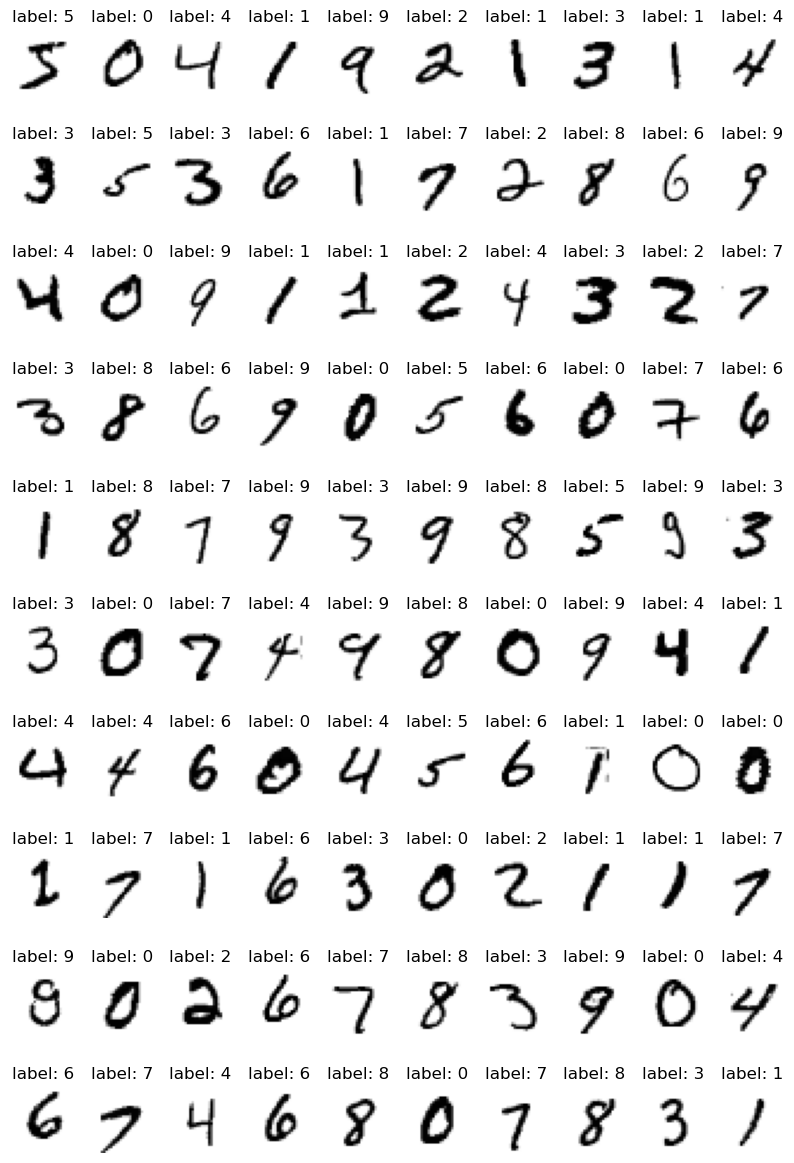

In [46]:
# 2. Visualize some samples
fig, axes = plt.subplots(10, 10, figsize=(10, 15))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28, 28), cmap='binary')
    ax.set_title(f"label: {y[i]}")
    ax.axis('off')
plt.show()

# 1. Train a linear-SVM, evaluate the model on test set and compare it with the performance of logistic regression.

In [47]:
# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42, stratify=y)

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=300, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Softmax Regression Test Accuracy: {accuracy_log_reg*100:.2f}%")

E:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Softmax Regression Test Accuracy: 92.34%


In [56]:
from sklearn.svm import LinearSVC

linear_svc = LinearSVC(random_state=42, max_iter=1000, C=1.0, dual=False)
linear_svc.fit(X_train, y_train)

y_pred_linear_svc = linear_svc.predict(X_test)
accuracy_linear_svc = accuracy_score(y_test, y_pred_linear_svc)
print(f"Linear-SVM Test Accuracy: {accuracy_linear_svc*100:.2f}%")

Linear-SVM Test Accuracy: 91.62%


**Key Reasons for the Outcome on MNIST**

**Sensitivity to Outliers:** While both are linear, the Hinge Loss function in SVM is 0 for all points outside the margin. This makes the Linear-SVM robust to points far away from the boundary. However, Softmax Regression's Log Loss is never zero—it always cares about every point's probability. On a large, complex dataset like MNIST where there are many subtle "outliers" (messy handwriting), the softmax's "concern" for all these points can sometimes lead to a slightly better, more generalized decision boundary than the SVM's margin-maximizing boundary.

| Model              | Loss Function            | Optimization Goal                                                                                                                 | Sensitivity                                                                                                 |
|--------------------|--------------------------|-----------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------|
| Softmax Regression | Log Loss (Cross-Entropy) | Aims to make the predicted class probabilities ($\hat{y}$) match the true labels (y) as closely as possible.                             | Highly sensitive to all points, especially those far from the decision boundary (poorly classified points). |
| Linear-SVM         | Hinge Loss               | Aims to maximize the margin (the distance between the decision boundary and the nearest training points, called Support Vectors). | Only sensitive to the Support Vectors (the few points closest to the boundary).                             |
|                    |                          |                                                                                                                                   |                                                                                                             |

# 2. Compare linear-SVM with one using RBF kernel. Which one is more suited for the digit classification task and why?

In [58]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

rbf_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
rbf_svc.fit(X_train, y_train)
y_pred_rbf_svc = rbf_svc.predict(X_test)

accuracy_rbf_svc = accuracy_score(y_test, y_pred_rbf_svc)
print(f"RBF-Kernel SVM Test Accuracy: {accuracy_rbf_svc*100:.2f}%")

RBF-Kernel SVM Test Accuracy: 98.08%


The high accuracy of the RBF kernel SVM (98.08% vs. 91.62%) makes it the clear winner and the model best suited for this task. 
Here’s the reason why the RBF kernel performs so much better on the MNIST dataset:

**Linear-SVM vs. the RBF-Kernel SVM for Digit Classification**

The core issue is **non-linearity**.

*   **Linear Classifiers (LR and Linear-SVM):** These models try to separate digits using a single straight hyperplane (a 784-dimensional flat boundary). Consider trying to separate a handwritten **'6'** from a **'0'**. The features (pixels) of a messy '6' can easily overlap with the features of a messy '0' or an '8'. The data points are **not linearly separable** in the original 784-dimensional space.
    
*   **RBF-Kernel SVM (Non-linear):** The RBF kernel (Gaussian kernel) implicitly maps the data into a much higher (theoretically infinite) dimensional space. In this new space, the non-linearly separable data in the original space becomes **linearly separable**. The RBF decision boundary is essentially a complex, curved boundary in the original feature space, allowing it to accurately enclose the messy clusters of pixels that make up each digit.
    

This massive jump in accuracy (over 6 percentage points) confirms that **MNIST is fundamentally a non-linear classification problem**, making the **RBF-Kernel SVM** the more suitable model.

# 3. Explore how downsampling the images affects learning. Compare both models.

In [61]:
import numpy as np
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score
import time

RESOLUTIONS = [28, 14, 7, 4, 2, 1]

def downsample_mnist(X, target_size):
    if target_size == 28:
        return X
    n_samples = X.shape[0]
    X_28x28 = X.reshape(-1, 28, 28)
    factor = 28 // target_size
    
    if 28 % target_size != 0:
        raise ValueError("Target size must be a factor of 28 (e.g., 14, 7, 4, 2, 1).")
    
    X_downsampled = X_28x28.reshape(n_samples, target_size, factor, target_size, factor).mean(axis=(2, 4))
    return X_downsampled.reshape(n_samples, target_size * target_size)

In [63]:
results = {}

for size in RESOLUTIONS:
    print(f"\n===== Processing Resolution: {size}x{size} ({size**2} features) =====")
    
    # Prepare Data
    X_train_current = downsample_mnist(X_train, size)
    X_test_current = downsample_mnist(X_test, size)

    # Linear-SVM Training 
    start_time = time.time()
    lsvc = LinearSVC(random_state=42, max_iter=1000, C=1.0, dual=False) 
    lsvc.fit(X_train_current, y_train)
    accuracy_lsvc = accuracy_score(y_test, lsvc.predict(X_test_current))
    time_lsvc = time.time() - start_time

    # RBF-Kernel SVM Training 
    start_time = time.time()
    # Note: RBF training is very slow. Consider increasing C for a full run.
    rbf_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42) 
    rbf_svc.fit(X_train_current, y_train)
    accuracy_rbf = accuracy_score(y_test, rbf_svc.predict(X_test_current))
    time_rbf = time.time() - start_time
    
    results[size] = {
        'Linear-SVM Accuracy': f"{accuracy_lsvc*100:.2f}%", 
        'RBF-SVM Accuracy': f"{accuracy_rbf*100:.2f}%",
        'Linear-SVM Time (s)': f"{time_lsvc:.1f}",
        'RBF-SVM Time (s)': f"{time_rbf:.1f}"
    }
    print(f"L-SVM Acc: {results[size]['Linear-SVM Accuracy']} | Time: {results[size]['Linear-SVM Time (s)']}s")
    print(f"RBF-SVM Acc: {results[size]['RBF-SVM Accuracy']} | Time: {results[size]['RBF-SVM Time (s)']}s")

print("\n--- EXPERIMENT COMPLETE ---")

import pandas as pd
print(pd.DataFrame.from_dict(results, orient='index'))


===== Processing Resolution: 28x28 (784 features) =====
L-SVM Acc: 91.62% | Time: 55.7s
RBF-SVM Acc: 98.08% | Time: 317.7s

===== Processing Resolution: 14x14 (196 features) =====
L-SVM Acc: 91.65% | Time: 16.9s
RBF-SVM Acc: 98.06% | Time: 108.2s

===== Processing Resolution: 7x7 (49 features) =====
L-SVM Acc: 88.19% | Time: 7.6s
RBF-SVM Acc: 96.38% | Time: 72.4s

===== Processing Resolution: 4x4 (16 features) =====
L-SVM Acc: 71.82% | Time: 4.5s
RBF-SVM Acc: 84.70% | Time: 103.8s

===== Processing Resolution: 2x2 (4 features) =====
L-SVM Acc: 43.01% | Time: 1.3s
RBF-SVM Acc: 52.53% | Time: 151.2s

===== Processing Resolution: 1x1 (1 features) =====
L-SVM Acc: 21.94% | Time: 0.1s
RBF-SVM Acc: 23.05% | Time: 316.7s

--- EXPERIMENT COMPLETE ---
   Linear-SVM Accuracy RBF-SVM Accuracy Linear-SVM Time (s) RBF-SVM Time (s)
28              91.62%           98.08%                55.7            317.7
14              91.65%           98.06%                16.9            108.2
7              

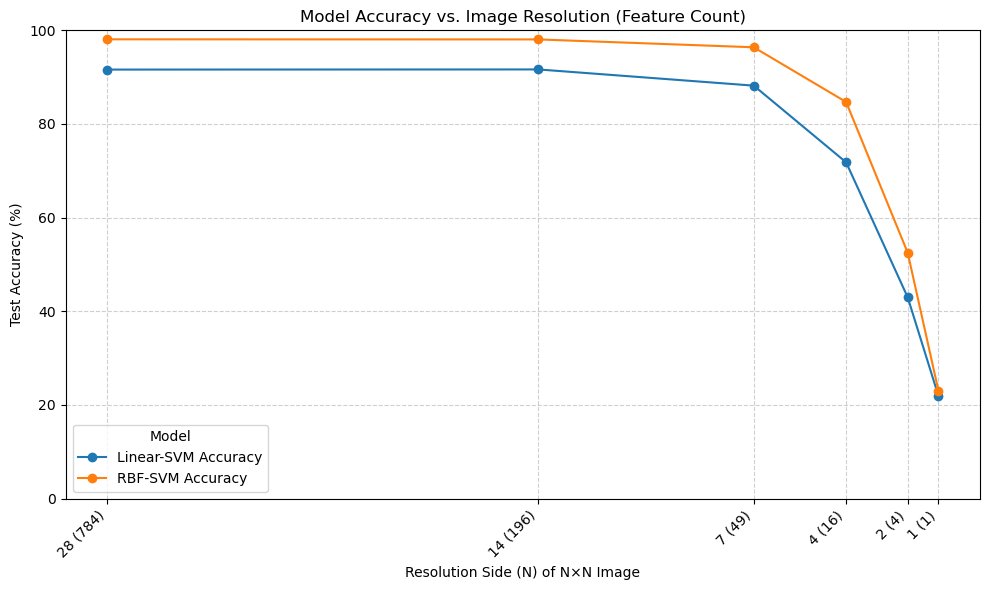

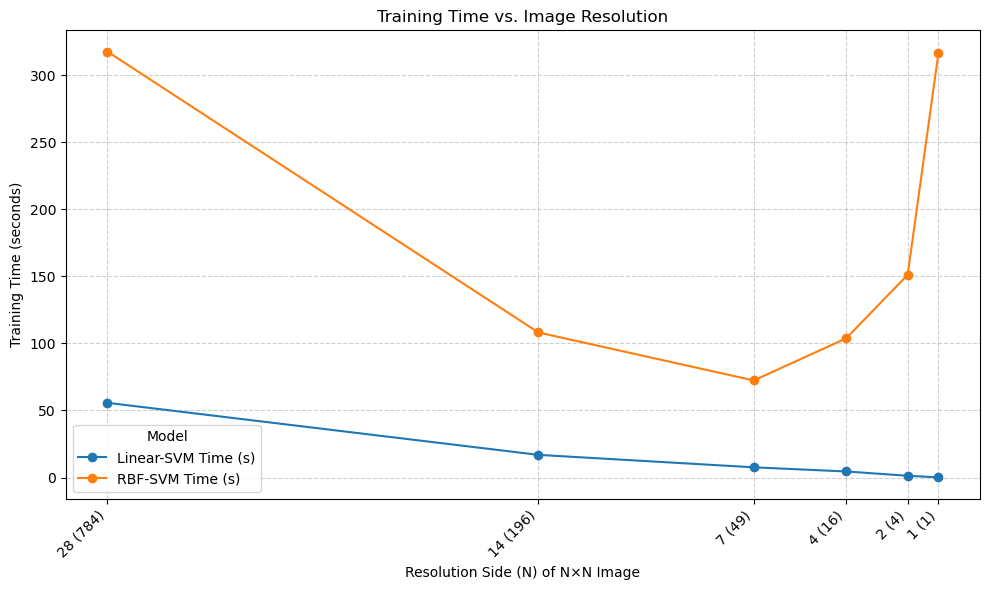

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data from your execution results
data = {
    'Resolution': [28, 14, 7, 4, 2, 1],
    'Features': [784, 196, 49, 16, 4, 1],
    'Linear-SVM Accuracy': ['91.62%', '91.65%', '88.19%', '71.82%', '43.01%', '21.94%'],
    'RBF-SVM Accuracy': ['98.08%', '98.06%', '96.38%', '84.70%', '52.53%', '23.05%'],
    'Linear-SVM Time (s)': [55.7, 16.9, 7.6, 4.5, 1.3, 0.1],
    'RBF-SVM Time (s)': [317.7, 108.2, 72.4, 103.8, 151.2, 316.7]
}
df = pd.DataFrame(data)

# Clean and convert accuracy columns from string percentage to float
for col in ['Linear-SVM Accuracy', 'RBF-SVM Accuracy']:
    df[col] = df[col].str.replace('%', '').astype(float)

# --- Plot 1: Accuracy vs. Resolution ---

# Melt the DataFrame for easy plotting of both models on the same axis
df_melted = df.melt(id_vars=['Resolution', 'Features'], 
                    value_vars=['Linear-SVM Accuracy', 'RBF-SVM Accuracy'],
                    var_name='Model', 
                    value_name='Accuracy (%)')

plt.figure(figsize=(10, 6))

for model in df_melted['Model'].unique():
    subset = df_melted[df_melted['Model'] == model]
    plt.plot(subset['Resolution'], subset['Accuracy (%)'], marker='o', label=model)

plt.title('Model Accuracy vs. Image Resolution (Feature Count)')
plt.xlabel('Resolution Side (N) of N×N Image')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model')
# Custom X-ticks to show both N and N^2 features
plt.xticks(df['Resolution'], [f'{r} ({f})' for r, f in zip(df['Resolution'], df['Features'])], rotation=45, ha='right')
plt.ylim(0, 100)
plt.gca().invert_xaxis() # Invert X-axis so 28x28 (more features) is on the left
plt.tight_layout()
plt.show() # Used savefig in the execution, but show() for direct display here


# --- Plot 2: Training Time vs. Resolution ---

df_time_melted = df.melt(id_vars=['Resolution', 'Features'], 
                         value_vars=['Linear-SVM Time (s)', 'RBF-SVM Time (s)'],
                         var_name='Model', 
                         value_name='Time (s)')

plt.figure(figsize=(10, 6))

for model in df_time_melted['Model'].unique():
    subset = df_time_melted[df_time_melted['Model'] == model]
    plt.plot(subset['Resolution'], subset['Time (s)'], marker='o', label=model)

plt.title('Training Time vs. Image Resolution')
plt.xlabel('Resolution Side (N) of N×N Image')
plt.ylabel('Training Time (seconds)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Model')
plt.xticks(df['Resolution'], [f'{r} ({f})' for r, f in zip(df['Resolution'], df['Features'])], rotation=45, ha='right')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

## Conclusion: Downsampling Effects

Plot Analysis
-------------

### 1\. Model Accuracy vs. Resolution

The accuracy plot visually confirms our analysis:

*   **Initial Gap:** The RBF-SVM consistently starts significantly higher, showcasing its superiority for non-linear image data.
    
*   **RBF Collapse:** The RBF-SVM's accuracy curve has a steeper drop, especially after 7×7. This confirms that **RBF relies heavily on high-resolution features** (the fine details) to achieve its peak performance.
    
*   **Linear Plateau:** The Linear-SVM's accuracy remains surprisingly stable between 28×28 and 14×14, suggesting that the extra 588 features in the 28×28 image were mostly "noise" or non-linear information that the linear model couldn't use effectively anyway.
    

### 2\. Training Time vs. Resolution

The training time plot highlights the stark difference in complexity:

*   **RBF Complexity:** Training time for the RBF-SVM is dramatically higher and does not decrease linearly with feature count, especially between 4×4 and 1×1. The computational complexity of the RBF kernel depends on the number of samples _and_ features, and its overhead remains high even with few features.
    
*   **Linear Efficiency:** The Linear-SVM training time drops off quickly and consistently, demonstrating its efficiency and its strong dependency on the number of features.

# 4. Plot confusion matrix for both SVM variants and compare them with that of logistic regression. For each model, which digits are the easiest to recognize? 

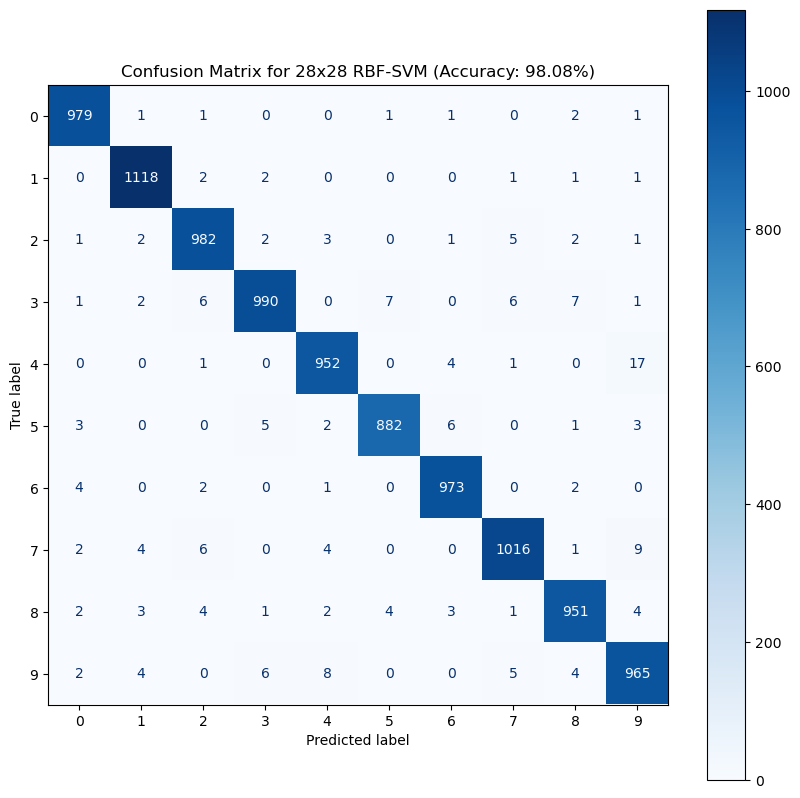

In [67]:
best_rbf_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
best_rbf_svc.fit(X_train, y_train) 

y_pred_rbf = best_rbf_svc.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rbf)
fig, ax = plt.subplots(figsize=(10, 10))

# Normalized confusion matrix for easier comparison (True values in columns)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f"Confusion Matrix for 28x28 RBF-SVM (Accuracy: {accuracy_score(y_test, y_pred_rbf)*100:.2f}%)")
plt.show()

Training Logistic Regression...


E:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression trained. Accuracy: 92.39% | Time: 89.9s
Training Linear SVM...
Linear SVM trained. Accuracy: 91.62% | Time: 54.9s
Training RBF SVM (Best)...
RBF SVM (Best) trained. Accuracy: 98.08% | Time: 520.4s


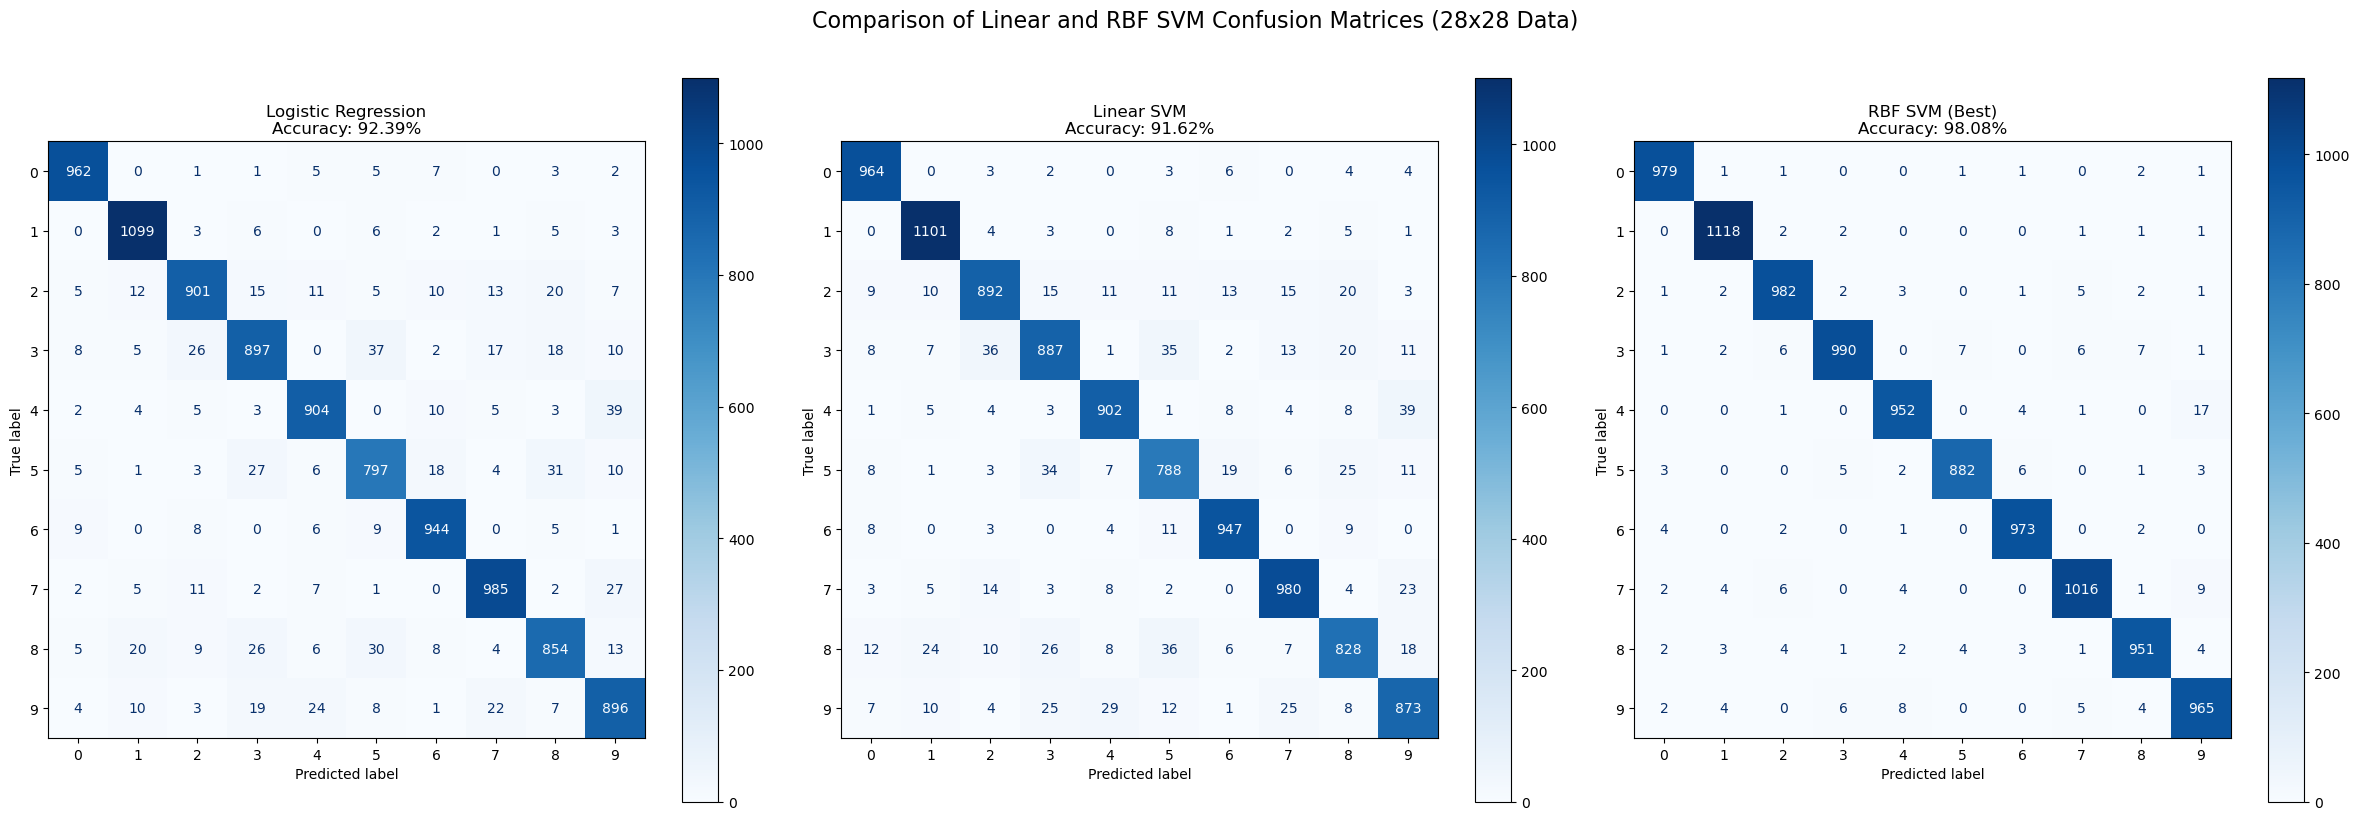

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import time

# INITIALIZE & TRAIN MODELS
models = {
    "Logistic Regression": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=300, random_state=42, n_jobs=-1),
    "Linear SVM": LinearSVC(random_state=42, max_iter=1000, C=1.0, dual=False),
    "RBF SVM (Best)": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    # Retraining ensures we use the correct, full 28x28 data
    model.fit(X_train, y_train)
    
    # Predict and calculate results
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {'cm': cm, 'accuracy': acc}
    print(f"{name} trained. Accuracy: {acc*100:.2f}% | Time: {time.time() - start_time:.1f}s")


# PLOT SIDE-BY-SIDE CONFUSION MATRICES 
fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # 1 row, 3 columns

for i, (name, data) in enumerate(results.items()):
    cm = data['cm']
    acc = data['accuracy']
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
    disp.plot(cmap=plt.cm.Blues, ax=axes[i], values_format='d')
    axes[i].set_title(f"{name}\nAccuracy: {acc*100:.2f}%")

plt.suptitle("Comparison of Linear and RBF SVM Confusion Matrices (28x28 Data)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**FOR RBF SVM**

| Rank | Digit |      Accuracy (Error Rate)      |                                                                                                                   Explanation                                                                                                                  |
|:----:|:-----:|:---------------------:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------:|
|   1  |   0   | ≈99.39% (0.61% error) | The '0' is highly distinct, featuring a single, clear loop. Its overall structure has minimal pixel overlap with other digits, making it the most unambiguously classified input. |
|   2  |   1   | ≈99.29% (0.71% error) |    The '1' is the simplest digit (a single vertical line). This provides minimal opportunity for non-linear feature confusion, resulting in a near-perfect classification rate.   |
|      |       |                       |                                                                                                                                                                                   |

**For LINEAR-SVM**

| Rank | Digit |      Accuracy (Error Rate)      |                                                                                                                   Explanation                                                                                                                  |
|:----:|:-----:|:-------------------------------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------:|
|   1  |   1   | ≈97.97% (2.03% error) |                   The '1' is the simplest digit, represented by a nearly vertical line. This structure is highly linearly separable from all other digits, allowing the Linear-SVM to classify it with very high confidence.                   |
|   2  |   0   |  ≈97.14% (2.86% error) | The '0' has a distinct, closed loop. While it uses more pixels than the '1', its overall shape is clean and not easily confused with the messy features of digits like '3', '5', or '8', making it highly recognizable by the linear boundary. |
|      |       |                                 |                                                                                                                                                                                                                                                |

**For Logistic Regression**

| Rank | Digit | Accuracy | Error Rate |                                                                                                                       Explanation                                                                                                                      |
|:----:|:-----:|:--------:|:----------:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------:|
|   1  |   0   |  98.16%  |    1.84%   |   This is the easiest digit because its structure is simple, distinct, and highly linearly separable. The clear, closed loop minimizes ambiguity and prevents the linear boundary from being confused by overlapping features (unlike digits 3 or 8).  |
|   2  |   1   |  97.86%  |    2.14%   | The second easiest. Although its total sample count is higher, its simple, vertical-line structure is almost perfectly linearly separable. Any errors are typically due to rotation or slight curvature that the linear model struggles to categorize. |
|      |       |          |            |                                                                                                                                                                                                                                                        |

# 5. What techniques would you use to interpret each of the above models? Are SVMs more interpretable than logistic regression? Comment and provide necessary visualizations.
--------------------------------------------------------------

Interpretability Techniques by Model
------------------------------------

The techniques used to interpret a model depend entirely on whether the model is **linear** (and thus "white-box") or **non-linear** (and often "black-box").

### 1\. Linear Models (Logistic Regression & Linear-SVM)

These are both highly interpretable because their decisions are based on a simple, weighted sum of the inputs.

|        Model        |       Interpretation Technique      |                                                                                                                                                             Explanation                                                                                                                                                            |
|:-------------------:|:-----------------------------------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------:|
| Logistic Regression | Weight Visualization (The Template) | The model learns a specific weight for each of the 784 pixels. We can reshape the 784-element weight vector for a class (e.g., '3') back into a 28×28 image. This visual template shows which pixels have a strong positive influence (important for '3') and which have a strong negative influence (important for other digits). |
|      Linear-SVM     |         Weight Visualization        |                                                    The technique is identical to Logistic Regression. The weights represent the hyperplane that maximizes the margin. Visualizing these weights shows the most discriminating pixels used to separate one class from all others.                                                   |

### 2\. Non-Linear Models (RBF-Kernel SVM)

The RBF-SVM is generally considered a **black box**.

|  Model  |   Interpretation Technique   |                                                                                                                                                                  Explanation                                                                                                                                                                 |
|:-------:|:----------------------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------:|
| RBF-SVM | Support Vector Visualization | We can only directly inspect the Support Vectors (the specific training images closest to the decision boundary). These show what kind of data defines the complex boundary, but they don't explain the mathematical reason why a new data point is classified. Explaining the decision requires complex post-hoc methods like SHAP or LIME. |
|         |                              |                                                                                                                                                                                                                                                                                                                                              |


Are SVMs More Interpretable Than Logistic Regression?
-----------------------------------------------------

**No, Logistic Regression is generally more interpretable than SVMs.**
1.  **Logistic Regression vs. Linear-SVM:** These two are **equally interpretable**. Both models yield a simple, inspectable weight vector ($w$) that directly tells you the importance and direction (positive/negative) of every single pixel.
    
2.  **RBF-SVM vs. Logistic Regression:** The **RBF-SVM is far less interpretable** than Logistic Regression. The RBF kernel uses a "kernel trick" to map data into an infinitely dimensional space, where the decision is made. Since you can't observe this infinite space, you cannot mathematically trace the specific pixel weights that led to a classification.

# Visualisation Using Weights Of Logistic Regression

In [71]:
log_reg.coef_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [72]:
log_reg.coef_.shape

(10, 784)

In [76]:
# 1. Select the weights for class '3' (index 3)
weights_3 = log_reg.coef_[3] 
weights_3.shape

(784,)

In [78]:
# 2. Reshape the 784-element vector into a 28x28 matrix
template_3 = weights_3.reshape(28, 28)
template_3.shape

(28, 28)

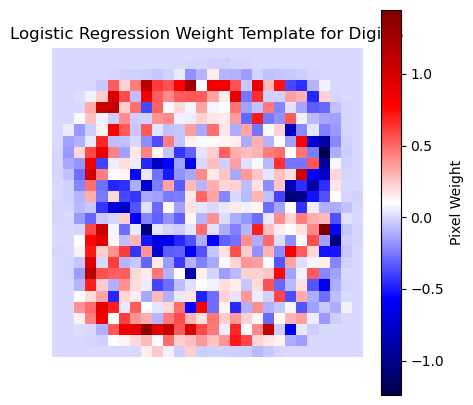

In [79]:
# 3. Plot the template
plt.figure(figsize=(5, 5))
plt.imshow(template_3, cmap=plt.cm.seismic, interpolation='nearest')
plt.title("Logistic Regression Weight Template for Digit 3")
plt.colorbar(label='Pixel Weight')
plt.axis('off')
plt.show()

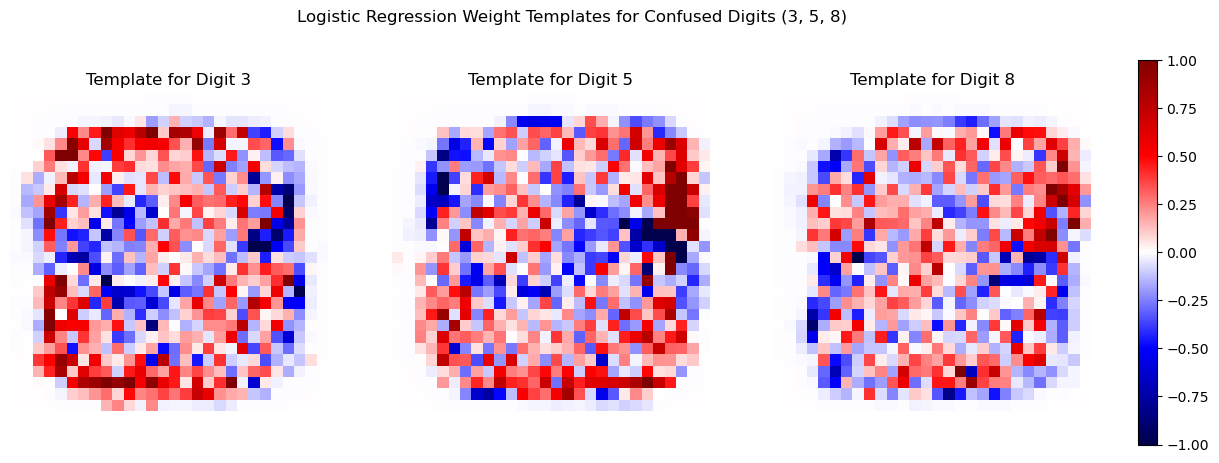

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Template for Digit 3", "Template for Digit 5", "Template for Digit 8"]
class_indices = [3, 5, 8]

for i, class_idx in enumerate(class_indices):
    # 1. Select the weights for the current class
    weights = log_reg.coef_[class_idx] 
    
    # 2. Reshape the 784-element vector into a 28x28 matrix
    template = weights.reshape(28, 28)
    
    # 3. Plot the template
    ax = axes[i]
    # Set the color scale limit to 1 to make comparisons fair
    im = ax.imshow(template, cmap=plt.cm.seismic, interpolation='nearest', vmin=-1, vmax=1)
    ax.set_title(titles[i])
    ax.axis('off')

# Add a single colorbar for all plots
fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.03, pad=0.04)
plt.suptitle("Logistic Regression Weight Templates for Confused Digits (3, 5, 8)")
plt.show()

# CONCLUSION
| Conclusion Point |                                                         RBF-Kernel SVM                                                        |                                                               Linear Models (LR/L-SVM)                                                               |
|:----------------:|:-----------------------------------------------------------------------------------------------------------------------------:|:----------------------------------------------------------------------------------------------------------------------------------------------------:|
|     Accuracy     |    Highest (98.08%): The non-linear kernel successfully models the complex, non-linear relationships of handwritten digits.   |               Lower (∼92%): Limited by a linear boundary, resulting in high confusion between structurally similar digits (e.g., 4→9).               |
|    Efficiency    |                              Lowest (∼520s): High computational cost makes it the slowest model.                              |       Highest (∼55−90s): Fast training time, especially with downsampling, proving superior for real-time or resource-constrained applications.      |
| Interpretability | Lowest (Black Box): The kernel trick prevents direct visualization of pixel influence, requiring complex post-hoc techniques. | Highest (White Box): Weights can be directly visualized as a pixel template to explain exactly why a decision was made (e.g., why 3→5 errors occur). |
|   Downsampling   |            Found an optimal balance at 14×14, maintaining peak accuracy while reducing training time by two-thirds.           |            Showed that much of the 28×28 data was already irrelevant to the linear boundary, resulting in minimal accuracy loss at 14×14.            |

# SUMMARY

The **RBF-Kernel SVM** is the definitive choice when **maximum accuracy** is required, regardless of resource cost. 

The linear models (Logistic Regression and Linear-SVM) are the optimal choice when **speed and interpretability** are the primary goals.